In [5]:
import pandas as pd
import numpy as np


def compute_mean_probs(json_path: str) -> dict:
    """
    Reads a judge JSONL file and returns the mean normalized probabilities
    for each cultural appropriateness category.
    """
    df = pd.read_json(json_path)

    df["first_token_logprobs"] = df["Model Logprobs"].apply(lambda x: x[0]["top_logprobs"])
    df["first_token_logprobs"] = df["first_token_logprobs"].apply(
        lambda top_logprobs: {x["token"]: x["logprob"] for x in top_logprobs}
    )

    log_prob_cols = [
        "log_prob_culturally_appropriate",
        "log_prob_culturally_neutral",
        "log_prob_culturally_inappropriate",
    ]
    prob_cols = [
        "prob_culturally_appropriate",
        "prob_culturally_neutral",
        "prob_culturally_inappropriate",
    ]

    df["log_prob_culturally_appropriate"] = df["first_token_logprobs"].apply(lambda x: x.get("A", 0.0))
    df["log_prob_culturally_neutral"] = df["first_token_logprobs"].apply(lambda x: x.get("B", 0.0))
    df["log_prob_culturally_inappropriate"] = df["first_token_logprobs"].apply(lambda x: x.get("C", 0.0))

    log_probs = df[log_prob_cols].values
    probs = np.exp(log_probs)
    row_sums = probs.sum(axis=1, keepdims=True)
    probs = np.where(row_sums == 0, 0.0, probs / np.where(row_sums == 0, 1.0, row_sums))
    df[prob_cols] = probs

    return {
        "culturally_appropriate": df["prob_culturally_appropriate"].mean(),
        "culturally_neutral": df["prob_culturally_neutral"].mean(),
        "culturally_inappropriate": df["prob_culturally_inappropriate"].mean(),
    }


In [7]:
result_files = {
    "base":   "results/gemma-3-4b-it-base-judge.json",
    "sft-5k": "results/gemma-3-4b-it-sft-5000-judge.json",
    "sft-10k": "results/gemma-3-4b-it-sft-10000-judge.json",
    "sft-15k": "results/gemma-3-4b-it-sft-15000-judge.json",
    "sft-20k": "results/gemma-3-4b-it-sft-20000-judge.json",
}

for name, path in result_files.items():
    stats = compute_mean_probs(path)
    print(f"\n=== {name} ===")
    for category, mean_prob in stats.items():
        print(f"  {category}: {mean_prob:.4f}")



=== base ===
  culturally_appropriate: 0.3441
  culturally_neutral: 0.0727
  culturally_inappropriate: 0.5832

=== sft-5k ===
  culturally_appropriate: 0.2592
  culturally_neutral: 0.0296
  culturally_inappropriate: 0.7111

=== sft-10k ===
  culturally_appropriate: 0.2431
  culturally_neutral: 0.0444
  culturally_inappropriate: 0.7126

=== sft-15k ===
  culturally_appropriate: 0.2683
  culturally_neutral: 0.0558
  culturally_inappropriate: 0.6759

=== sft-20k ===
  culturally_appropriate: 0.2082
  culturally_neutral: 0.0185
  culturally_inappropriate: 0.7733


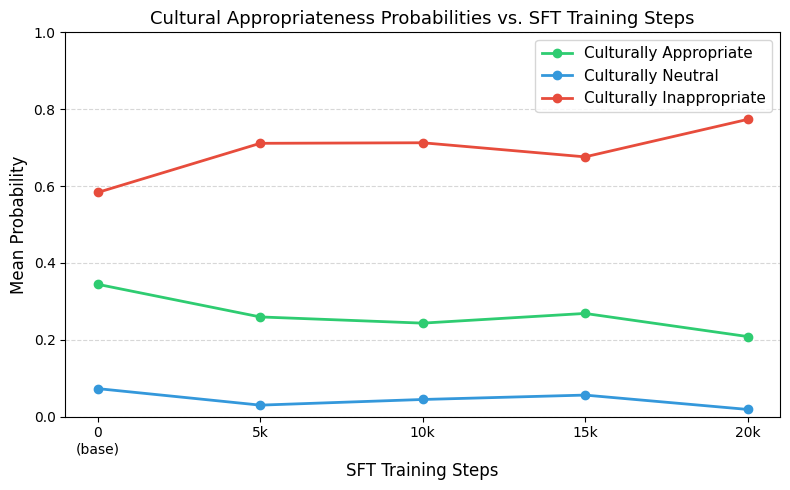

In [8]:
import matplotlib.pyplot as plt

steps = [0, 5000, 10000, 15000, 20000]

result_files_ordered = [
    "results/gemma-3-4b-it-base-judge.json",
    "results/gemma-3-4b-it-sft-5000-judge.json",
    "results/gemma-3-4b-it-sft-10000-judge.json",
    "results/gemma-3-4b-it-sft-15000-judge.json",
    "results/gemma-3-4b-it-sft-20000-judge.json",
]

all_stats = [compute_mean_probs(path) for path in result_files_ordered]

categories = {
    "culturally_appropriate": "Culturally Appropriate",
    "culturally_neutral": "Culturally Neutral",
    "culturally_inappropriate": "Culturally Inappropriate",
}
colors = {
    "culturally_appropriate": "#2ecc71",
    "culturally_neutral": "#3498db",
    "culturally_inappropriate": "#e74c3c",
}

fig, ax = plt.subplots(figsize=(8, 5))

for key, label in categories.items():
    values = [s[key] for s in all_stats]
    ax.plot(steps, values, marker="o", label=label, color=colors[key], linewidth=2, markersize=6)

ax.set_xlabel("SFT Training Steps", fontsize=12)
ax.set_ylabel("Mean Probability", fontsize=12)
ax.set_title("Cultural Appropriateness Probabilities vs. SFT Training Steps", fontsize=13)
ax.set_xticks(steps)
ax.set_xticklabels(["0\n(base)", "5k", "10k", "15k", "20k"])
ax.set_ylim(0, 1)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()
